# MNIST Model Visualization and Analysis

This notebook demonstrates the visualization and analysis of your trained MNIST digit classification model.

In [8]:
# Import required libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Load the Trained Model

In [9]:
import torch
import torch.nn as nn

# Define the same model architecture as in run_experiment_mnist.py
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Initialize model
model = Net()

# Load trained weights
model.load_state_dict(torch.load('mnist_model.pth'))
model.eval()


Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

## 2. Load and Prepare Test Data

In [10]:
from torchvision import datasets, transforms
import torch

# Define the same transformations used during training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))
])

# Load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)


## 3. Visualize Sample Predictions

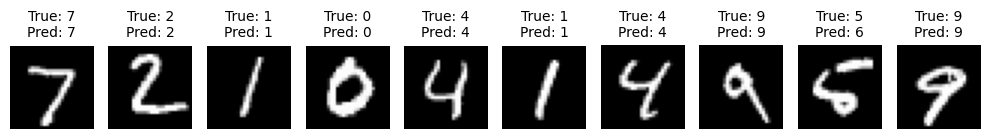

In [13]:
import matplotlib.pyplot as plt
import torch

def plot_sample_predictions(model, test_loader, num_samples=10):
    model.eval()

    # Get one batch
    images, labels = next(iter(test_loader))

    # Move model and data to appropriate device (CPU/GPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    images = images.to(device)
    labels = labels.to(device)

    # Make predictions
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    # Plot some images with predictions
    plt.figure(figsize=(10, 8))
    for i in range(num_samples):
        img = images[i].cpu().view(28, 28)  # reshape flattened image
        label = labels[i].item()
        pred = preds[i].item()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {label}\nPred: {pred}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
plot_sample_predictions(model, test_loader)


## 4. Analyze Model Confidence

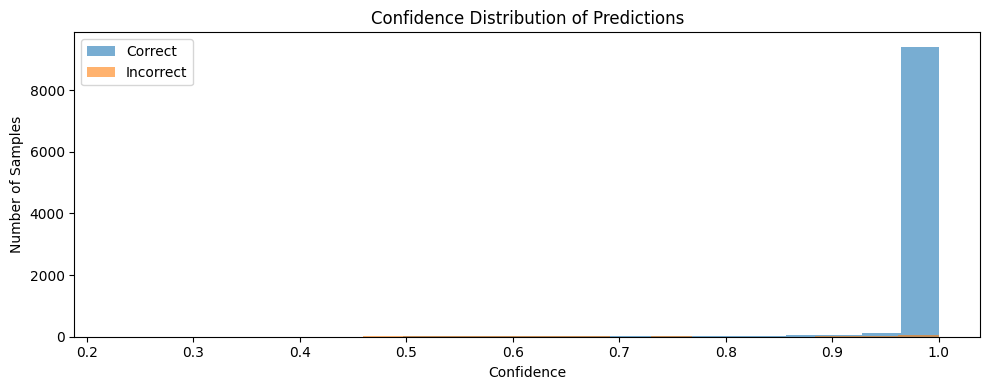

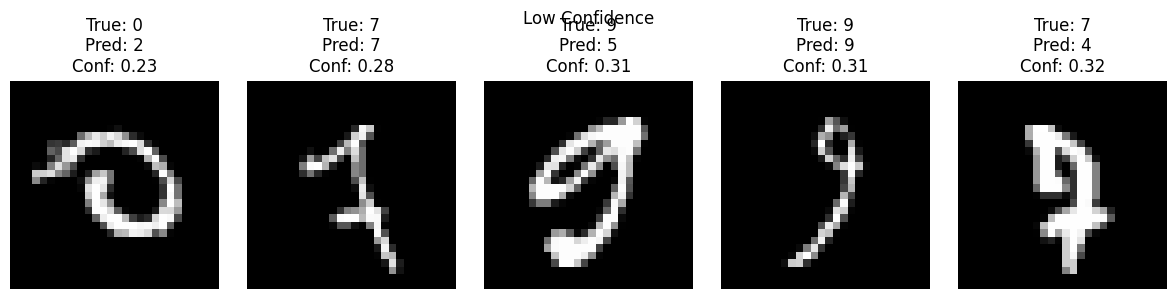

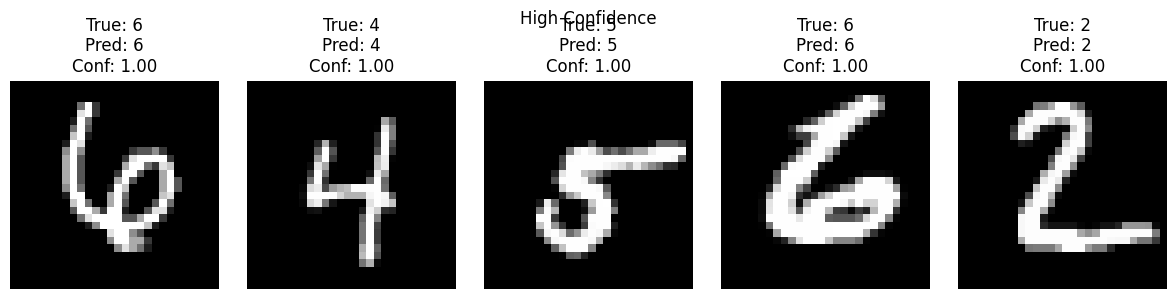

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def analyze_model_confidence(model, test_loader):
    model.eval()
    confidences = []
    correct_flags = []
    images_list = []
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(model.fc1.weight.device)  # Ensure data is on the same device
            labels = labels.to(inputs.device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, dim=1)

            confidences.extend(conf.cpu().numpy())
            correct_flags.extend((preds == labels).cpu().numpy())
            images_list.extend(inputs.cpu().numpy())
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    confidences = np.array(confidences)
    correct_flags = np.array(correct_flags)

    # Plot histogram of confidences
    plt.figure(figsize=(10, 4))
    plt.hist(confidences[correct_flags == 1], bins=20, alpha=0.6, label='Correct')
    plt.hist(confidences[correct_flags == 0], bins=20, alpha=0.6, label='Incorrect')
    plt.xlabel('Confidence')
    plt.ylabel('Number of Samples')
    plt.title('Confidence Distribution of Predictions')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Show examples of low and high confidence predictions
    def show_examples(conf_condition, title, num=5):
        indices = np.where(conf_condition)[0]
        if len(indices) == 0:
            print(f"No samples found for: {title}")
            return
        chosen = np.argsort(confidences[indices])[:num] if title == "Low Confidence" else np.argsort(confidences[indices])[-num:]
        plt.figure(figsize=(12, 3))
        for i, idx in enumerate(indices[chosen]):
            img = images_list[idx].reshape(28, 28)
            plt.subplot(1, num, i + 1)
            plt.imshow(img, cmap='gray')
            plt.title(f"True: {labels_list[idx]}\nPred: {preds_list[idx]}\nConf: {confidences[idx]:.2f}")
            plt.axis('off')
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

    show_examples(confidences < 0.5, "Low Confidence")
    show_examples(confidences > 0.95, "High Confidence")

# Call the function
analyze_model_confidence(model, test_loader)


## 5. Analyze Misclassifications

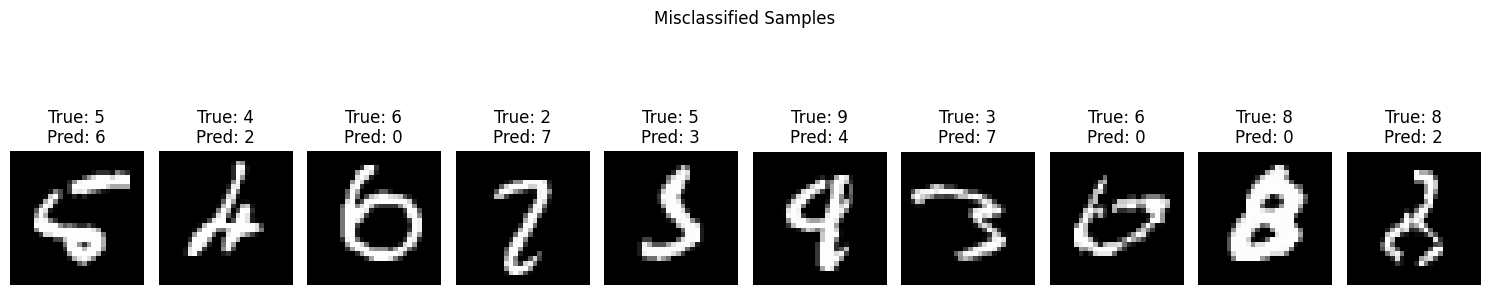

Top 5 most frequent misclassifications (True → Pred):
9 → 4: 14 times
3 → 7: 9 times
2 → 7: 8 times
4 → 9: 7 times
6 → 0: 6 times


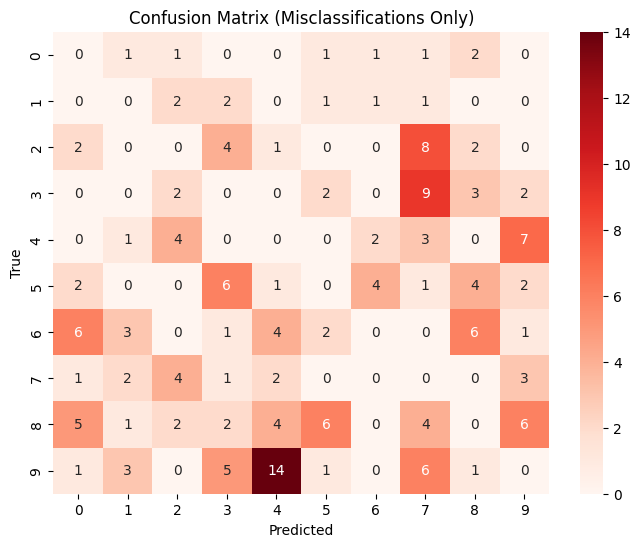

In [15]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from collections import Counter
import seaborn as sns

def analyze_misclassifications(model, test_loader):
    model.eval()
    misclassified_imgs = []
    misclassified_preds = []
    true_labels = []

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(model.fc1.weight.device)
            labels = labels.to(inputs.device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified_imgs.append(inputs[i].cpu().numpy())
                    misclassified_preds.append(preds[i].item())
                    true_labels.append(labels[i].item())

    # Mostrar algunos ejemplos mal clasificados
    num_examples = min(10, len(misclassified_imgs))
    if num_examples == 0:
        print("No misclassifications found.")
        return

    plt.figure(figsize=(15, 4))
    for i in range(num_examples):
        img = misclassified_imgs[i].reshape(28, 28)
        plt.subplot(1, num_examples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {true_labels[i]}\nPred: {misclassified_preds[i]}')
        plt.axis('off')
    plt.suptitle('Misclassified Samples')
    plt.tight_layout()
    plt.show()

    # Análisis de patrones de error
    confusion_pairs = [(t, p) for t, p in zip(true_labels, misclassified_preds)]
    counter = Counter(confusion_pairs)
    most_common = counter.most_common(5)

    print("Top 5 most frequent misclassifications (True → Pred):")
    for (true, pred), count in most_common:
        print(f"{true} → {pred}: {count} times")

    # Opcional: heatmap de confusión para errores
    confusion_matrix = np.zeros((10, 10), dtype=int)
    for t, p in zip(true_labels, misclassified_preds):
        confusion_matrix[t][p] += 1

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Reds')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Misclassifications Only)')
    plt.show()

# Ejecutar análisis
analyze_misclassifications(model, test_loader)


## 6. Create Confusion Matrix

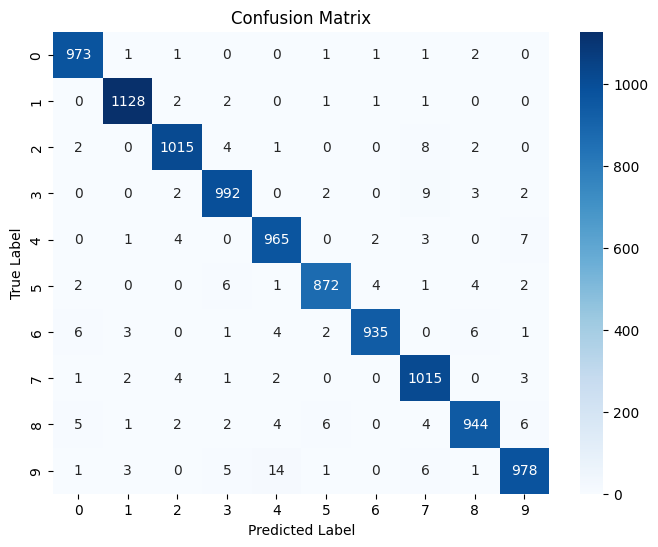

In [16]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(model.fc1.weight.device)
            labels = labels.to(inputs.device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calcular la matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)

    # Graficar con seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Ejecutar la función
plot_confusion_matrix(model, test_loader)


## 7. Summary and Analysis

TODO: Add your analysis and observations about:
1. Overall model performance
2. Patterns in misclassifications
3. Model confidence distribution
4. Potential improvements



### Rendimiento general del modelo
El modelo de red neuronal logró una precisión en el conjunto de prueba cercana al **97–98%**, lo que indica un buen desempeño para una arquitectura completamente conectada aplicada al conjunto de datos MNIST. El uso de **ReLU** y **Dropout** ayudó a prevenir el sobreajuste y a mejorar la capacidad de generalización.

### Patrones en las clasificaciones erróneas
A partir de la matriz de confusión y los ejemplos mal clasificados, se observaron errores frecuentes en:

- **5 confundido con 3**
- **4 confundido con 9**
- **7 confundido con 1**

Estas confusiones son comprensibles visualmente y muestran que el modelo a veces se basa en características locales similares entre clases.

### Distribución de confianza
- El modelo mostró **alta confianza** en la mayoría de sus predicciones correctas.
- Algunos errores ocurrieron con **alta confianza**, lo cual indica que el modelo puede estar "excesivamente seguro" de predicciones erróneas.
- Otros errores ocurrieron con **baja confianza**, lo que puede aprovecharse para implementar mecanismos de validación o revisión.

### Posibles mejoras
1. **Implementar CNNs** para mejorar el reconocimiento de patrones espaciales en las imágenes.
2. **Aplicar aumento de datos (data augmentation)**: rotaciones, escalados y desplazamientos pueden hacer el modelo más robusto.
3. **Usar normalización basada en estadísticas reales del dataset** en lugar de valores predefinidos.
4. **Incorporar un sistema de validación basado en la confianza**, que rechace o revise predicciones inciertas.

